In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
!date

Wed Apr  1 04:25:54 PDT 2026


# Examine output of new line list observer, generated with new `ssimulate` command

In [2]:
dname = '/home/abie/vivarium_results/united_states_of_america/2026_03_31_20_27_10/results'
fname = dname + '/simulant_line_list.parquet'
df = pd.read_parquet(fname)
df

,simulant_id,draw,random_seed,location,date_of_birth,date_of_death,date_of_bbbm_incidence,date_of_treatment_initiation,date_of_treatment_cessation,date_of_mci_incidence,date_of_dementia_incidence,input_draw_number,intervention_scenario
0,0,457,4344,united_states_of_america,1941-03-29 22:58:40.265808744,2029-06-23,2020-06-16 07:24:02.944656017,NaT,NaT,2025-12-27,NaT,457,baseline
1,1,457,4344,united_states_of_america,1933-08-14 02:18:47.335794489,2024-12-28,2020-08-05 15:19:58.641075710,NaT,NaT,2022-07-02,2023-12-30,457,baseline
2,2,457,4344,united_states_of_america,1941-05-06 17:31:53.022310335,2027-12-25,2021-06-18 23:00:04.267798551,NaT,NaT,2033-06-18,NaT,457,baseline
3,3,457,4344,united_states_of_america,1944-03-31 02:18:31.999300212,2023-07-01,2018-04-18 01:37:52.753880956,NaT,NaT,2023-12-30,NaT,457,baseline
4,4,457,4344,united_states_of_america,1950-02-10 20:26:58.911913865,2030-06-22,2021-04-21 13:20:20.228226123,NaT,NaT,NaT,NaT,457,baseline
...,...,...,...,...,...,...,...,...,...,...,...,...,...
666447,333221,457,4344,united_states_of_america,2007-10-15 17:25:02.086413765,NaT,2100-09-25 00:00:00.000000000,NaT,NaT,NaT,NaT,457,bbbm_testing_and_treatment
666448,333222,457,4344,united_states_of_america,2008-12-14 00:33:16.870920532,NaT,2100-09-25 00:00:00.000000000,NaT,NaT,NaT,NaT,457,bbbm_testing_and_treatment
666449,333223,457,4344,united_states_of_america,2009-04-26 05:03:21.601001993,NaT,2100-09-25 00:00:00.000000000,NaT,NaT,NaT,NaT,457,bbbm_testing_and_treatment
666450,333224,457,4344,united_states_of_america,2008-12-03 11:45:41.293411820,NaT,2100-09-25 00:00:00.000000000,NaT,NaT,NaT,NaT,457,bbbm_testing_and_treatment


In [4]:
df_baseline = df.query("intervention_scenario == 'baseline'")
df_treatment = df.query("intervention_scenario == 'bbbm_testing_and_treatment'")

df_merged = pd.merge(df_baseline, df_treatment,
                     on=['simulant_id', 'draw', 'random_seed', 'location'],
                     suffixes=('_baseline', '_treatment'))
df_merged.iloc[0].sort_index()

date_of_bbbm_incidence_baseline           2020-06-16 07:24:02.944656017
date_of_bbbm_incidence_treatment          2020-06-16 07:24:02.944656017
date_of_birth_baseline                    1941-03-29 22:58:40.265808744
date_of_birth_treatment                   1941-03-29 22:58:40.265808744
date_of_death_baseline                              2029-06-23 00:00:00
date_of_death_treatment                             2029-06-23 00:00:00
date_of_dementia_incidence_baseline                                 NaT
date_of_dementia_incidence_treatment                                NaT
date_of_mci_incidence_baseline                      2025-12-27 00:00:00
date_of_mci_incidence_treatment                     2025-12-27 00:00:00
date_of_treatment_cessation_baseline                                NaT
date_of_treatment_cessation_treatment                               NaT
date_of_treatment_initiation_baseline                               NaT
date_of_treatment_initiation_treatment                          

In [7]:
df_treated = df_merged.dropna(
    subset=['date_of_treatment_initiation_treatment']
    )

In [14]:
(df_treated.date_of_death_treatment - df_treated.date_of_death_baseline).dropna().sort_values()

3349         0 days
214295       0 days
214303       0 days
214319       0 days
214325       0 days
            ...    
74337     8736 days
119573    8736 days
142858    8918 days
49548    10192 days
68341    10556 days
Length: 14501, dtype: timedelta64[ns]

In [15]:
(df_treated.date_of_death_treatment - df_treated.date_of_death_baseline).mean()

Timedelta('227 days 08:18:36.171298532')

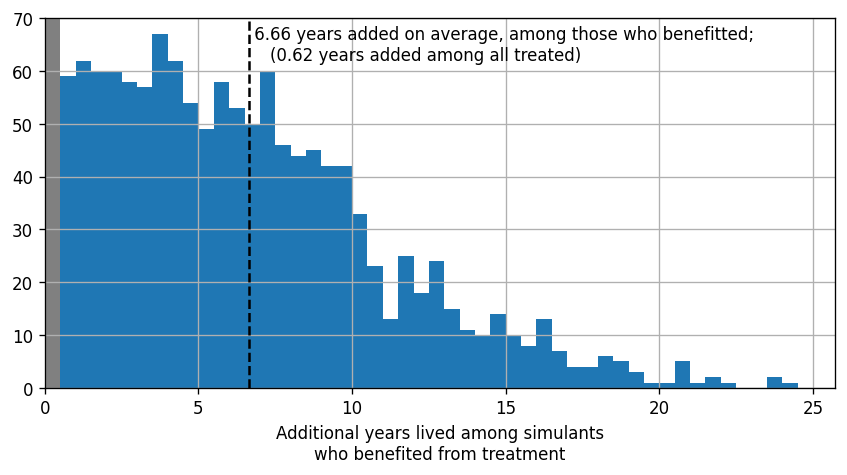

In [36]:
plt.figure(figsize=(8.5, 4.0), dpi=120)

years_added = (
    (
        df_treated.date_of_death_treatment - df_treated.date_of_death_baseline
    ) / pd.Timedelta(days=365.25)
)

years_added.hist(bins=np.arange(.5,25,.5))
years_added.hist(bins=[0,.5], color='grey')
plt.axis(xmin=0, ymax=70)

mean_years_added = years_added[years_added>0].mean()
plt.axvline(mean_years_added, color='k', linestyle='dashed')
plt.text(mean_years_added, 65, f' {mean_years_added:.2f} years added on average, among those who benefitted;\n'
         f'    ({years_added.mean():.2f} years added among all treated)', ha='left', va='center', color='k')
plt.xlabel('Additional years lived among simulants\nwho benefited from treatment');

In [38]:
print(f'Mean years added, among all treated:           {years_added.mean():.2f}')
print(f'Mean years added, among those who benefitted:  {years_added[years_added>0].mean():.2f}')

Mean years added, among all treated:           0.62
Mean years added, among those who benefitted:  6.66


In [12]:
df_treated.iloc[1000].sort_index()

date_of_bbbm_incidence_baseline                     2037-12-12 00:00:00
date_of_bbbm_incidence_treatment                    2037-12-12 00:00:00
date_of_birth_baseline                    1964-07-16 07:21:41.838642695
date_of_birth_treatment                   1964-07-16 07:21:41.838642695
date_of_death_baseline                              2047-11-30 00:00:00
date_of_death_treatment                             2047-11-30 00:00:00
date_of_dementia_incidence_baseline                                 NaT
date_of_dementia_incidence_treatment                                NaT
date_of_mci_incidence_baseline                      2046-06-02 00:00:00
date_of_mci_incidence_treatment                     2046-06-02 00:00:00
date_of_treatment_cessation_baseline                                NaT
date_of_treatment_cessation_treatment               2046-06-02 00:00:00
date_of_treatment_initiation_baseline                               NaT
date_of_treatment_initiation_treatment              2040-12-08 0